**1.Load and explore data**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


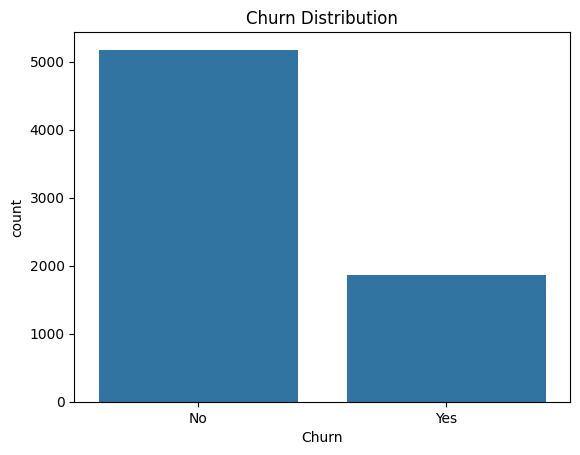

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [4]:
# This shows you what proportion of customers churn (class imbalance).
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print(df['Churn'].value_counts(normalize=True))

In [7]:
df.describe()
# You’ll notice TotalCharges is actually an object (string) even though it should be numeric. We’ll fix this next.

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


3. Data cleaning

3.1 Convert TotalCharges to numeric

In [8]:
# Convert TotalCharges to numeric (coerce errors to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values
print(df['TotalCharges'].isna().sum())

# Simple approach: drop rows with NaN in TotalCharges
# (There are only a small number)
df = df.dropna(subset=['TotalCharges'])

11


3.2 Drop customerID

In [9]:
# customerID is just an identifier, not useful for prediction.
df = df.drop('customerID', axis=1)

4. Encode categorical variables

In [11]:
# You used pd.get_dummies(df, drop_first=True) which is a solid approach. Let’s do it after cleaning.
# One-hot encode all categorical variables, drop_first=True to avoid dummy trap
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [12]:
# Confirm target column
[col for col in df_encoded.columns if 'Churn' in col]

['Churn_Yes']

5. Train–test split

In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn_Yes', axis=1)  # features
y = df_encoded['Churn_Yes']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# random_state=42 for reproducibility.
# stratify=y keeps churn proportion similar in train and test.

6. Train a baseline model (Logistic Regression)

In [15]:
# We’ll start with Logistic Regression because it’s simple and interpretable.
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

7. Evaluate the model


In [16]:
# Use accuracy, confusion matrix, and classification report.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = log_reg.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8031
Confusion Matrix:
 [[916 117]
 [160 214]]

Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.89      0.87      1033
        True       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



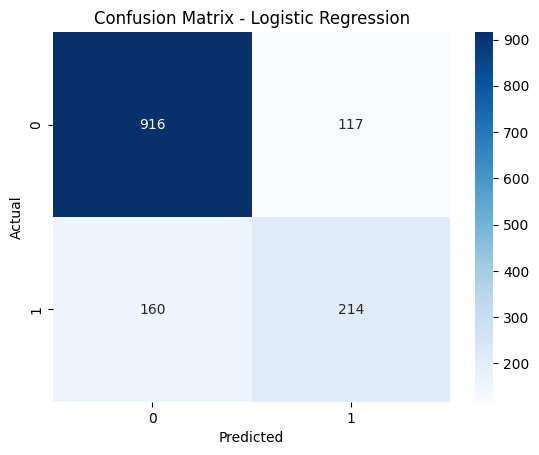

In [17]:
# Optionally, visualize the confusion matrix:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()
# This gives you:

# Precision and recall for churn vs non-churn
# How many churners you are correctly identifying (recall)
# How many non-churners you are correctly identifying (recall)

In [ ]:
#  How many non-churners you are correctly identifying (recall)


8.Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7867803837953091

Random Forest Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



9.  Feature importance
To understand which features drive churn (with Random Forest):

In [20]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Show top 10 features
for i in range(10):
    print(f"{i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")
#  This tells you which features (e.g., tenure, Contract type, MonthlyCharges) are most important in predicting churn.

1. TotalCharges: 0.1943
2. tenure: 0.1685
3. MonthlyCharges: 0.1680
4. InternetService_Fiber optic: 0.0389
5. PaymentMethod_Electronic check: 0.0379
6. Contract_Two year: 0.0319
7. gender_Male: 0.0289
8. OnlineSecurity_Yes: 0.0273
9. PaperlessBilling_Yes: 0.0256
10. Partner_Yes: 0.0233


additional

In [21]:
# 1. Focus on recall for churners
# Right now overall accuracy is ~0.80, but recall for churn (True) is around 0.57 (logistic) and 0.51 (RF). In real churn problems, catching churners is more important than overall accuracy.
# Logistic Regression:
log_reg_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg_balanced.fit(X_train, y_train)

y_pred_bal = log_reg_balanced.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report (Balanced):\n",
      classification_report(y_test, y_pred_bal))

Accuracy: 0.7277896233120114

Classification Report (Balanced):
               precision    recall  f1-score   support

       False       0.91      0.70      0.79      1033
        True       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
# Random Forest:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_balanced.fit(X_train, y_train)

y_pred_rf_bal = rf_balanced.predict(X_test)
print("Random Forest (balanced) Accuracy:", accuracy_score(y_test, y_pred_rf_bal))
print("\nRF (balanced) Classification Report:\n",
      classification_report(y_test, y_pred_rf_bal))

Random Forest (balanced) Accuracy: 0.7903340440653873

RF (balanced) Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [23]:
# 2. Tune the decision threshold
# By default, models predict churn if probability > 0.5. You can lower the threshold to catch more churners.

# For Logistic Regression:
from sklearn.metrics import confusion_matrix, classification_report

# Get probabilities of class 1 (churn)
y_proba = log_reg.predict_proba(X_test)[:, 1]

# Example: use 0.4 threshold instead of 0.5
threshold = 0.4
y_pred_thr = (y_proba >= threshold).astype(int)

cm_thr = confusion_matrix(y_test, y_pred_thr)
print("Confusion Matrix (threshold=0.4):\n", cm_thr)
print("\nClassification Report (threshold=0.4):\n",
      classification_report(y_test, y_pred_thr))
# Lower threshold → higher churn recall, lower precision.

Confusion Matrix (threshold=0.4):
 [[844 189]
 [118 256]]

Classification Report (threshold=0.4):
               precision    recall  f1-score   support

       False       0.88      0.82      0.85      1033
        True       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



ROC-AUC: 0.8364


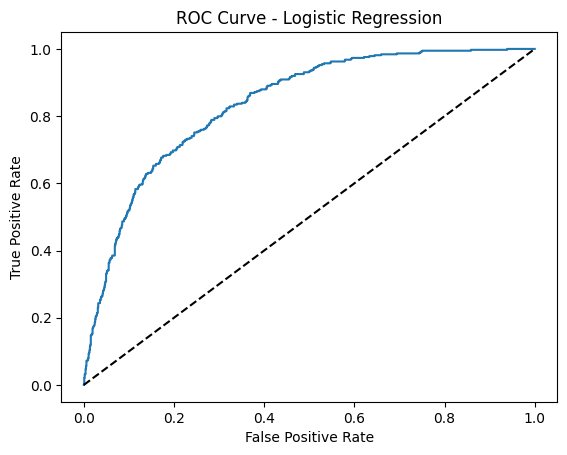

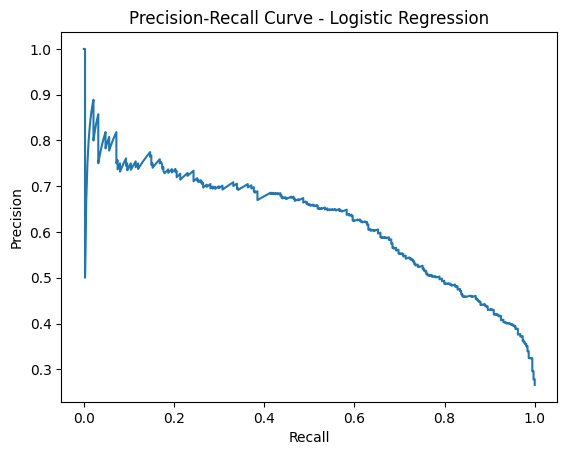

In [24]:
# 3. Use ROC–AUC and PR–AUC
# Accuracy is OK, but ROC-AUC and precision–recall AUC are better for imbalanced data
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

# Probabilities from logistic regression
y_proba = log_reg.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()

In [26]:
# 4. Try a gradient boosting model (often strong on tabular data)
# For this kind of dataset, XGBoost, LightGBM, or GradientBoostingClassifier often outperform RF.
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nGradient Boosting Classification Report:\n",
      classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7953091684434968

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

       False       0.84      0.89      0.86      1033
        True       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [27]:
# 5. Cross-validation and hyperparameter tuning (slightly advanced)
# Use GridSearchCV or RandomizedSearchCV to tune your best model:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf_grid = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf_grid,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)

Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best ROC-AUC: 0.845464927501673




1."Our model’s goal is to identify customers likely to churn so the business can target retention offers."

2.Summarize key metrics: accuracy, churn recall, ROC-AUC.

3.Show top features from feature importance and explain in plain language:

   a.Higher MonthlyCharges and lower tenure → more likely to churn.

   b.Fiber optic InternetService might be associated with higher churn vs DSL.

   c.Contract_Two year reduces churn risk, etc.

### **Short Project Summary**

*Project Title: Customer Churn Prediction for Telco Customers*

*Objective*

Build a machine learning model that predicts whether a customer will churn (leave the service) so the business can proactively target those customers with retention offers.

*Data*

We used the Telco Customer Churn dataset, which contains customer demographics, service details (internet, phone, add‑ons), contract information, and billing data. The target variable is Churn (Yes/No).

*Methodology*

*1.Data Cleaning*

  i.Converted TotalCharges from string to numeric and removed rows with missing values in this column.

ii.Dropped customerID since it is just an identifier and not useful for prediction.

*2.Feature Engineering & Encoding*

i.Applied one‑hot encoding to all categorical variables using pd.get_dummies(..., drop_first=True).

ii.Defined Churn_Yes as the target variable and used all remaining columns as features.

*3.Modeling*

i.Split the data into training and test sets (80/20) with stratification on the target.

ii.Trained several models:

  a)Logistic Regression (baseline)

 b)Random Forest Classifier

c)Gradient Boosting
Classifier

iii.Also trained a class‑balanced Logistic Regression and experimented with a lower decision threshold (0.4) to improve recall for churners.

*4Evaluation*

i.Used accuracy, precision, recall, F1-score, confusion matrix, and ROC‑AUC.

ii.Baseline Logistic Regression achieved about 0.80 accuracy, with recall for churn around 0.57.

iii.Using class weighting and a lower decision threshold increased churn recall (catching more churners) at the cost of some accuracy on non‑churners.

iv.Best Random Forest hyperparameters were selected with GridSearchCV, achieving a ROC‑AUC of around 0.845 on cross‑validation.

*Key Insights*
Feature importance analysis shows that churn is strongly related to:

i.TotalCharges and MonthlyCharges: customers paying higher charges are more likely to churn.

ii.Tenure: customers with shorter tenure are more likely to leave; long‑term customers are more stable.

iii.InternetService_Fiber optic: customers using fiber optic service show a higher tendency to churn compared to DSL.

iv.PaymentMethod_Electronic check and PaperlessBilling_Yes: these payment/billing options are associated with higher churn risk.

v.Contract_Two year: long‑term contracts significantly reduce churn risk.

*Conclusion*

The project delivers a working churn prediction pipeline that can identify high‑risk customers with reasonable accuracy and good recall, especially after tuning class weights and thresholds. These predictions can be used to prioritize retention campaigns (e.g., special offers for high‑risk, high‑value customers). Further work could include more advanced models (e.g., XGBoost), cost‑sensitive evaluation, and deployment as an API.